--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB

--- Numerical Distribution ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.52300

C:\Users\acer\AppData\Local\Temp\ipykernel_9816\57670292.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=['O']))
C:\Users\acer\AppData\Local\Temp\ipykernel_9816\57670292.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')
C:\Users\acer\AppData\Local\Temp\ipykernel_9816\57670292.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is d


All analytical plots successfully generated and exported!


<Figure size 640x480 with 0 Axes>

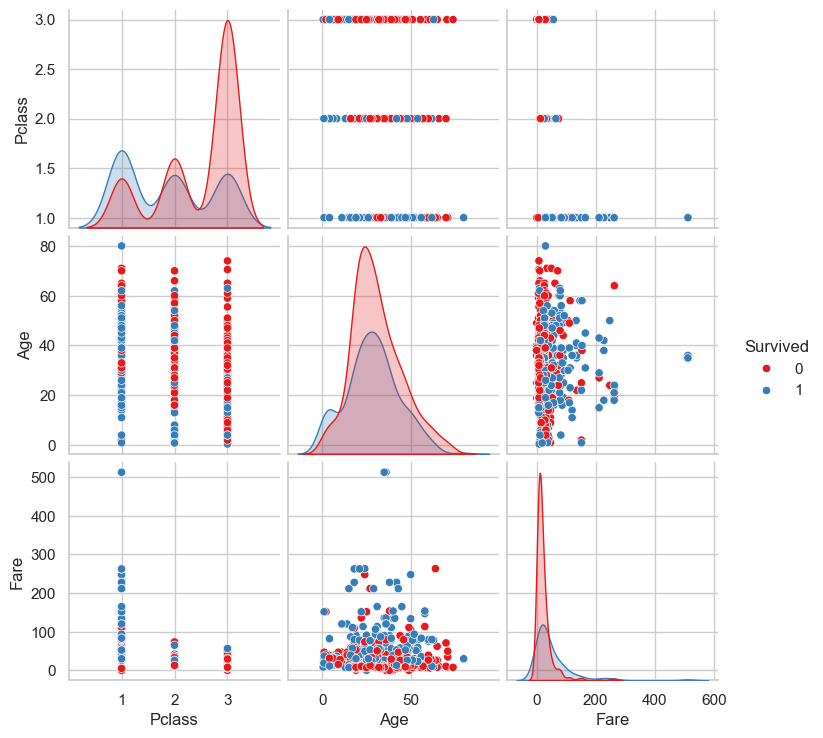

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization parameters
sns.set_theme(style="whitegrid")

# 1. Load the Dataset
df = pd.read_csv('train.csv')

# 2. Structural Inspection
print("--- Dataset Info ---")
df.info()

print("\n--- Numerical Distribution ---")
print(df.describe())

print("\n--- Categorical Distribution ---")
print(df.describe(include=['O']))

# 3. Target Distribution & Crosstabs
print("\n--- Survival Value Counts ---")
print(df['Survived'].value_counts())

print("\n--- Survival Rate by Gender (%) ---")
print(pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100)

print("\n--- Survival Rate by Passenger Class (%) ---")
print(pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100)

# ==========================================
# VISUALIZATION PIPELINE
# ==========================================

# Visual 1: Age Distribution Histogram
plt.clf()
sns.histplot(data=df, x='Age', kde=True, bins=30, color='skyblue')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('age_distribution.png')

# Visual 2: Fare Distribution Histogram
plt.clf()
sns.histplot(data=df, x='Fare', kde=True, bins=30, color='salmon')
plt.title('Fare Distribution of Passengers')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('fare_distribution.png')

# Visual 3: Fare Boxplot by Passenger Class
plt.clf()
sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')
plt.title('Fare Distribution across Passenger Classes')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Fare')
plt.tight_layout()
plt.savefig('fare_boxplot_by_pclass.png')

# Visual 4: Age Boxplot by Survival Status
plt.clf()
sns.boxplot(data=df, x='Survived', y='Age', palette='Set1')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.tight_layout()
plt.savefig('age_boxplot_by_survival.png')

# Visual 5: Scatterplot of Age vs Fare by Survival Status
plt.clf()
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', palette='coolwarm', alpha=0.7)
plt.title('Scatterplot of Age vs Fare by Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.tight_layout()
plt.savefig('age_fare_scatterplot.png')

# Visual 6: Correlation Heatmap
plt.clf()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(numerical_cols, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Titanic Dataset Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

# Visual 7: Comprehensive Pairplot Matrix
plt.clf()
pairplot_df = df[['Survived', 'Pclass', 'Age', 'Fare', 'Sex']].dropna()
g = sns.pairplot(pairplot_df, hue='Survived', palette='Set1', diag_kind='kde')
g.savefig('titanic_pairplot.png')

print("\nAll analytical plots successfully generated and exported!")